In [1]:
import warnings
warnings.filterwarnings('ignore')

from nrem_sc.constants import PROCESSED_DATA_PATH
from nrem_sc.utils import plot_intervals

import numpy as np
import pynapple as nap
import seaborn as sns
import umap
import umap.plot

from matplotlib import pyplot as plt

unit_id = "116b"
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)

# Load
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

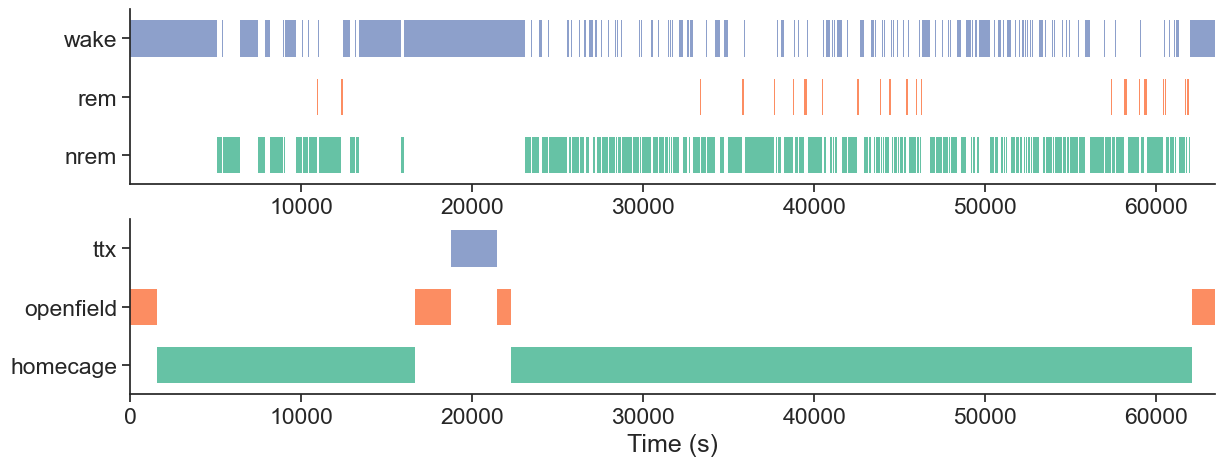

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5))

plot_intervals(sleep_states, column='state', palette='Set2', ax=ax1)
plot_intervals(sessions, column='label', palette='Set2', ax=ax2)

plt.show()

In [49]:
sessions[1].union(hd_angle.time_support)

  index     start      end
      0   1551.35  16644.5
      1  16663.1   18772.6
shape: (2, 2), time unit: sec.

In [56]:
BIN = 0.05
SMOOTH_STD = 0.1

epochs = sessions[1].union(hd_angle.time_support)
angle = hd_angle.bin_average(bin_size=BIN).to_numpy()
binned = hd_spikes.count(bin_size=BIN, ep=epochs)
frates = np.sqrt(binned.smooth(std=SMOOTH_STD))

index = len(frates) - len(angle)
t, frates = frates.times(), frates.to_numpy()

In [62]:
UMAP_NEIGHBORS = 250
UMAP_MIN_DIST = 0.2

reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=3, metric='correlation')
embeddings = reducer.fit_transform(frates)

In [ ]:
embds = nap.TsdFrame(t=t, d=embeddings, columns=['x', 'y', 'z'])

np.float64(19.978453658082454)

In [86]:
embds.restrict(sessions[1])

Time (s)           x        y         z
-----------  -------  -------  --------
1551.37225   7.80238  5.84957  1.31696
1551.42225   6.71177  4.26868  0.142259
1551.47225   6.60646  4.24616  0.122494
1551.52225   6.52619  4.17245  0.071113
1551.57225   6.42491  4.26725  0.21281
1551.62225   6.46098  4.3935   0.285584
1551.67225   6.31805  4.65542  0.383618
...
16644.17225  1.24967  5.77048  1.79577
16644.22225  1.28334  5.68663  1.72237
16644.27225  1.25151  5.56843  1.7553
16644.32225  1.27325  5.58477  1.76535
16644.37225  1.41177  5.49196  1.65953
16644.42225  1.71431  5.24693  1.34034
16644.47225  2.01699  4.9659   1.06749
dtype: float32, shape: (301863, 3)

In [ ]:
index #301863

301863

In [81]:
np.save(PROCESSED_DATA_PATH / unit_id / "combined_angle_prettx.npy", angle)

In [75]:
embds.save(PROCESSED_DATA_PATH / unit_id / "combined_umap_prettx.npz")

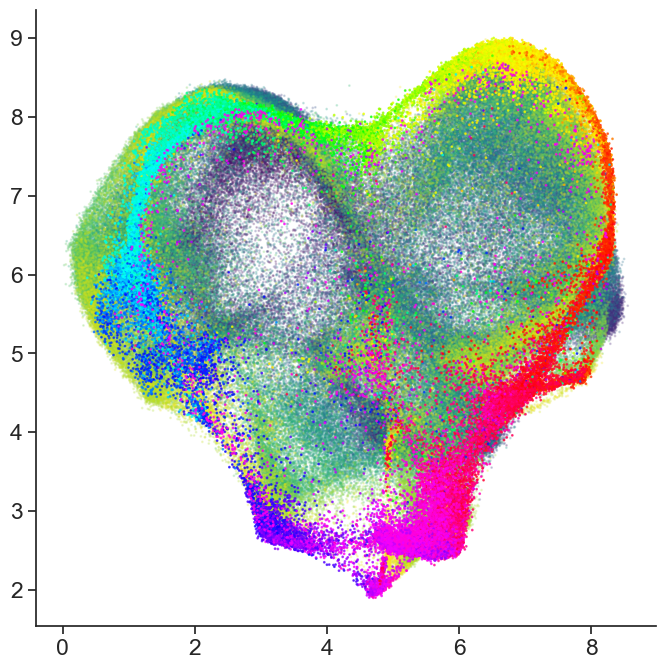

In [68]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(embeddings[:index, 0], embeddings[:index, 1], c=np.arange(embeddings[:index, 0].shape[0]), s=1, alpha=0.2, cmap='viridis')
ax.scatter(embeddings[index:, 0], embeddings[index:, 1], c=angle, cmap='hsv', s=1, alpha=0.7)
plt.show()

### Wake manifold

wake_rates shape: (10548, 81)


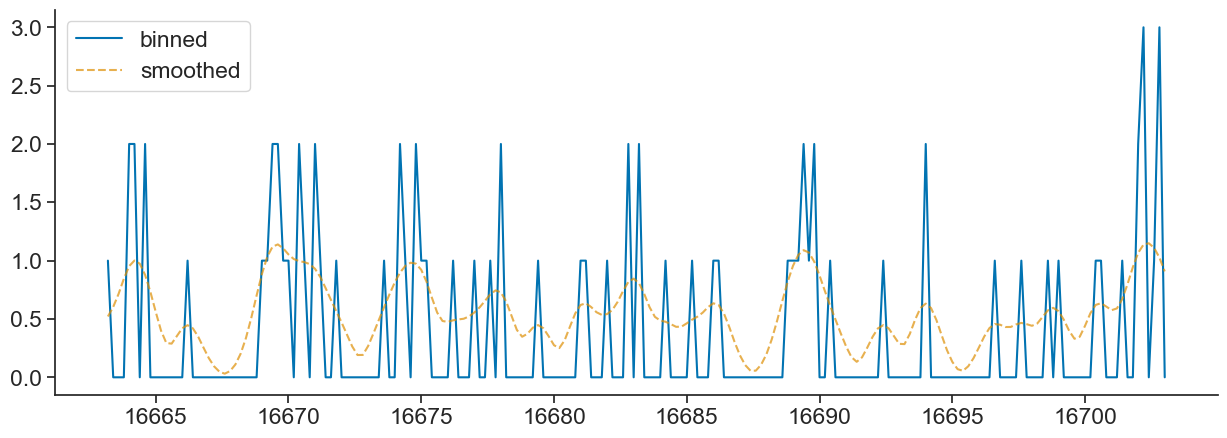

In [17]:
WAKE_BIN = 0.2
SMOOTH_STD = 0.4

angle = hd_angle.bin_average(bin_size=WAKE_BIN)
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=hd_angle.time_support)
wake_rates = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"wake_rates shape: {wake_rates.shape}")

# Visualize Smoothing effect
t_a, t_b = 0, 200
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(wake_rates[t_a:t_b, channel], '--', alpha=0.7)
plt.legend(['binned', 'smoothed'])
plt.show()

<Axes: >

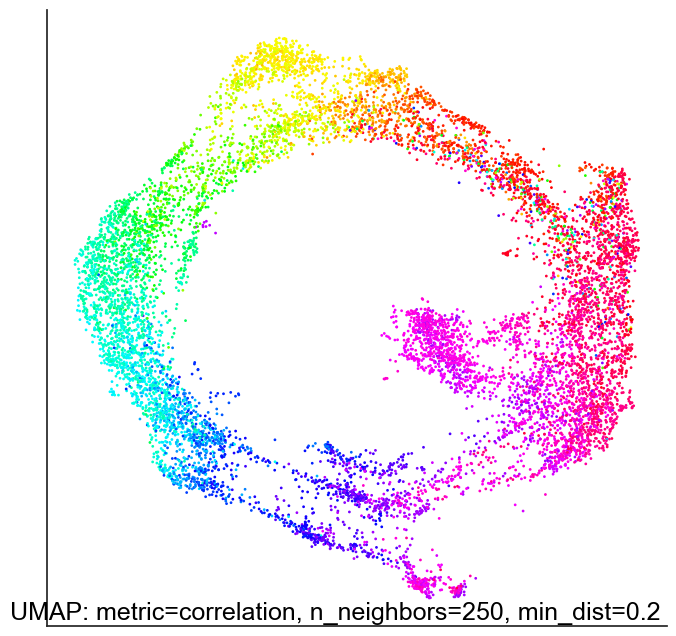

In [124]:
UMAP_NEIGHBORS = 250
UMAP_MIN_DIST = 0.2

reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='correlation')
reducer.fit(wake_rates)
umap.plot.points(reducer, values=angle.values, cmap='hsv')

### NREM projection

smooth_rate shape: (301863, 81)


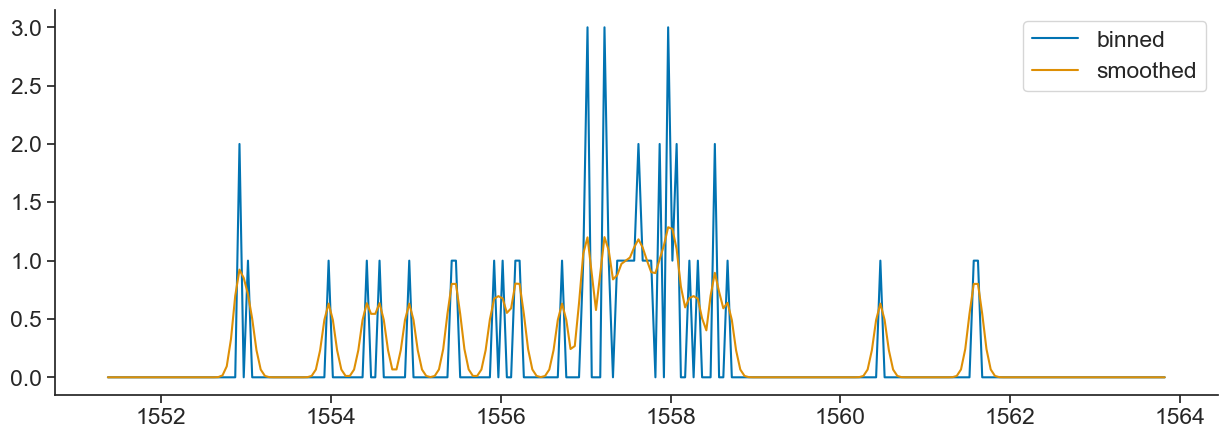

In [18]:
epochs = sessions[sessions['label'] == 'homecage'][0]

NREM_BIN = 0.05
SMOOTH_STD = 0.1

binned = hd_spikes.count(bin_size=NREM_BIN, ep=epochs)
smooth_rate = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"smooth_rate shape: {smooth_rate.shape}")

# Visualize smoothing effect
t_a, t_b = 0, 250
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(smooth_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])
plt.show()

In [31]:
wake_rates, w_t = wake_rates.to_numpy(), wake_rates.times()
smooth_rate, s_t = smooth_rate.to_numpy(), smooth_rate.times()

print(f"wake_rates shape: {wake_rates.shape}")
print(f"smooth_rate shape: {smooth_rate.shape}")
print(f"wake_rates time range: {w_t[0]} to {w_t[-1]}")
print(f"smooth_rate time range: {s_t[0]} to {s_t[-1]}")

wake_rates shape: (10548, 81)
smooth_rate shape: (301863, 81)
wake_rates time range: 16663.2 to 18772.6
smooth_rate time range: 1551.37225 to 16644.47225


In [32]:
index = len(smooth_rate)
combined = np.concatenate((smooth_rate, wake_rates), axis=0)
print(f"combined shape: {combined.shape}")

combined shape: (312411, 81)


In [ ]:
UMAP_NEIGHBORS = 250
UMAP_MIN_DIST = 0.2

reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=3, metric='correlation')
reducer.fit(wake_rates)

,n_neighbors,250
,n_components,2
,metric,'correlation'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.2
,spread,1.0


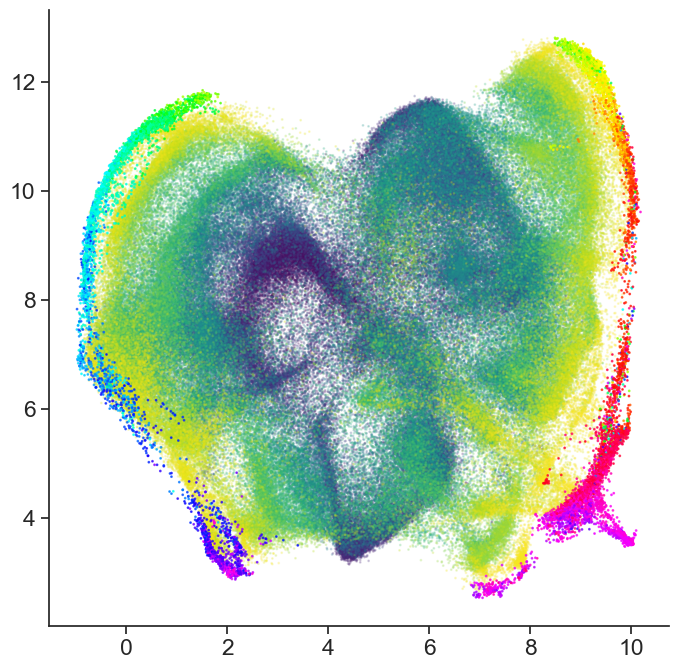

In [34]:
embeddings = reducer.embedding_

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(embeddings[:index, 0], embeddings[:index, 1], c=np.arange(embeddings[:index, 0].shape[0]), s=1, alpha=0.2, cmap='viridis')
ax.scatter(embeddings[index:, 0], embeddings[index:, 1], c=angle.values, cmap='hsv', s=1, alpha=0.7)
plt.show()

In [ ]:
sleep_embds = reducer.transform(smooth_rate)

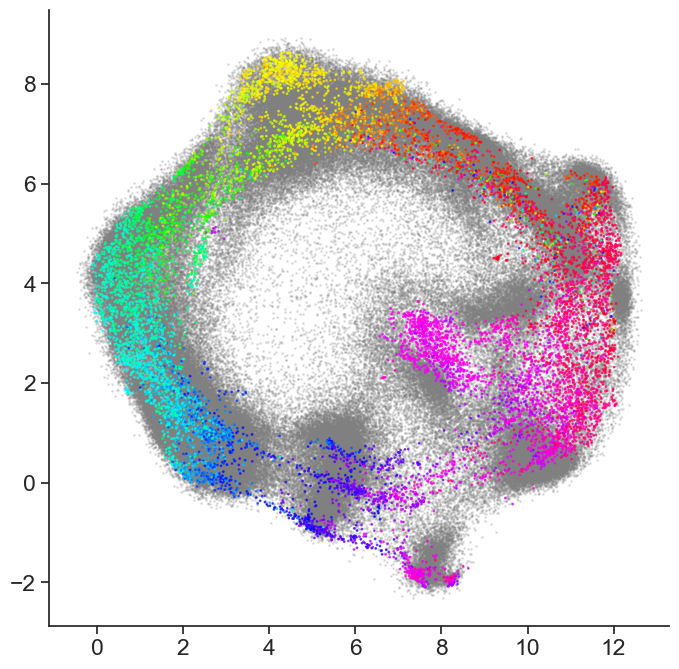

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(sleep_embds[:, 0], sleep_embds[:, 1], c='grey', s=1, alpha=0.2)
plt.scatter(reducer.embedding_[:, 0], reducer.embedding_[:, 1], c=angle.values, cmap='hsv', s=1, alpha=0.7)
plt.show()

In [ ]:
manifold = nap.TsdFrame(t=smooth_rate.t, d=sleep_embds, columns=['x', 'y'])